In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.utils import to_categorical



In [2]:
def load_and_preprocess_data(data_path, label_column_name, sample_fraction=0.1):
    # Load all CSV files from the directory
    all_files = glob.glob(os.path.join(data_path, '*.csv'))

    df_list = []
    print("Loading CSV files...")
    for filename in all_files:
        temp_df = pd.read_csv(filename)
        df_list.append(temp_df)

    df = pd.concat(df_list, ignore_index=True)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Check and update label column name if necessary
    if label_column_name not in df.columns:
        possible_label_columns = [col for col in df.columns if 'label' in col.lower()]
        if possible_label_columns:
            label_column_name = possible_label_columns[0]
            print(f"Using '{label_column_name}' as the label column.")
        else:
            raise KeyError(f"Label column '{label_column_name}' not found in dataframe.")

    # Map labels to 'Benign' and 'Malicious'
    df[label_column_name] = np.where(df[label_column_name] == 'BENIGN', 'Benign', 'Malicious')

    # Stratified sampling to maintain class distribution
    df = df.groupby(label_column_name, group_keys=False).apply(
        lambda x: x.sample(frac=sample_fraction, random_state=42)
    ).reset_index(drop=True)

    # Separate features and labels
    X = df.drop(columns=[label_column_name])
    y = df[label_column_name]

    return X, y


In [3]:
def preprocess_and_split(X, y, test_size=0.2, random_state=42):
    # Convert categorical features to numeric if any
    X = pd.get_dummies(X)

    # Identify numeric columns
    numeric_cols = X.select_dtypes(include=['float64', 'int64', 'uint8']).columns

    # Handle infinite values
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Impute missing values using median
    imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

    # Scale features using Min-Max Scaler
    scaler = MinMaxScaler()
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    y_encoded = to_categorical(y_encoded)

    # Split data with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_encoded, test_size=test_size, random_state=random_state, stratify=y
    )

    # Reshape data for RNN input (samples, time steps, features)
    time_steps = 1
    features = X_train.shape[1]

    X_train = X_train.reshape((X_train.shape[0], time_steps, features))
    X_test = X_test.reshape((X_test.shape[0], time_steps, features))

    return X_train, X_test, y_train, y_test, label_encoder.classes_


In [4]:
def correlation_selection(X, y, feature_number=10):
    # Combine X and y into a single DataFrame
    df = X.copy()
    df['Target'] = y

    # Calculate correlation matrix
    corr_matrix = df.corr()

    # Get correlation with target variable
    corr_with_target = corr_matrix['Target'].drop('Target')

    # Select top features based on absolute correlation
    top_features = corr_with_target.abs().sort_values(ascending=False).head(feature_number).index.tolist()

    print(f"Top {feature_number} features selected by correlation:")
    print(top_features)

    return top_features


In [5]:
def train_and_evaluate_model(X_train, X_test, y_train, y_test, class_names):
    num_classes = y_train.shape[1]
    time_steps = X_train.shape[1]
    input_dim = X_train.shape[2]

    # Define the RNN model
    model = Sequential()
    model.add(LSTM(units=64, input_shape=(time_steps, input_dim)))
    model.add(Dropout(0.5))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("\nTraining the RNN model...")
    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

    # Evaluate the model
    scores = model.evaluate(X_test, y_test, verbose=0)
    print("\nModel Performance:")
    print(f"Test Loss: {scores[0]:.4f}")
    print(f"Test Accuracy: {scores[1]:.4f}")

    # Predict classes
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=-1)
    y_true_classes = y_test.argmax(axis=-1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


In [6]:
def main():
    data_path = r'C:\Users\joshb\OneDrive\Documents\Final Project\CICDS 2017\MachineLearningCVE'
    label_column_name = 'Label'  # Update if necessary
    sample_fraction = 1.0  # Adjust sample fraction as needed

    # Step 1: Load and preprocess data
    print("Loading and preprocessing data...")
    X, y = load_and_preprocess_data(data_path, label_column_name, sample_fraction)

    # Step 2: Preprocess and split data
    print("Preprocessing and splitting data...")
    X_train, X_test, y_train, y_test, class_names = preprocess_and_split(X, y)
    
    # Step 4: Train and evaluate the RNN model
    train_and_evaluate_model(X_train, X_test, y_train, y_test, class_names)


Loading and preprocessing data...
Loading CSV files...


C:\Users\joshb\AppData\Local\Temp\ipykernel_10252\1045947770.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(label_column_name, group_keys=False).apply(


Preprocessing and splitting data...


C:\Users\joshb\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training the RNN model...
Epoch 1/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 110s 2ms/step - accuracy: 0.9515 - loss: 0.1114 - val_accuracy: 0.9736 - val_loss: 0.0649
Epoch 2/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 106s 2ms/step - accuracy: 0.9731 - loss: 0.0614 - val_accuracy: 0.9738 - val_loss: 0.0509
Epoch 3/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 122s 2ms/step - accuracy: 0.9766 - loss: 0.0534 - val_accuracy: 0.9781 - val_loss: 0.0478
Epoch 4/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 119s 2ms/step - accuracy: 0.9782 - loss: 0.0498 - val_accuracy: 0.9797 - val_loss: 0.0443
Epoch 5/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 112s 2ms/step - accuracy: 0.9789 - loss: 0.0478 - val_accuracy: 0.9808 - val_loss: 0.0418
Epoch 6/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 113s 2ms/step - accuracy: 0.9799 - loss: 0.0457 - val_accuracy: 0.9813 - val_loss: 0.0404
Epoch 7/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 112s 2ms/step - accuracy: 0.9802 - loss: 0.0450 - val_accuracy: 0.9839 - val_loss: 0.0389
Epoch 8/10
63692/63692 ━━━━━━━━━━━━

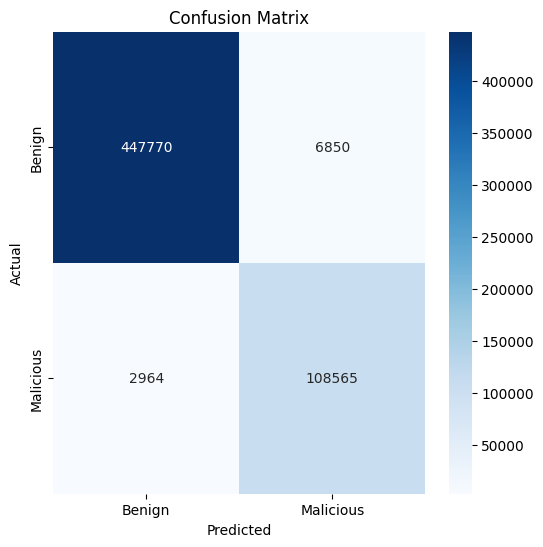

In [7]:
if __name__ == "__main__":
    main()
